<a href="https://colab.research.google.com/github/shivraaj98/Earthquake-Final/blob/main/final_earthquake_first_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving earthquake.csv to earthquake (1).csv
Final dataset size: 793
Train shape: (525, 10, 8)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 128)        │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,657 (307.25 KB)

 Trainable params: 78,657 (307.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 8.5208 - val_loss: 0.5935
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5137 - val_loss: 0.2088
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3493 - val_loss: 0.1860
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3411 - val_loss: 0.1804
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2852 - val_loss: 0.2137
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3272 - val_loss: 0.1809
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3137 - val_loss: 0.1883
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2707 - val_loss: 0.1671
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2918 - val_loss: 0.1564
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.3029 - val_loss: 0.1601
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2965 - val_loss: 0.1801
Epoch 12/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2

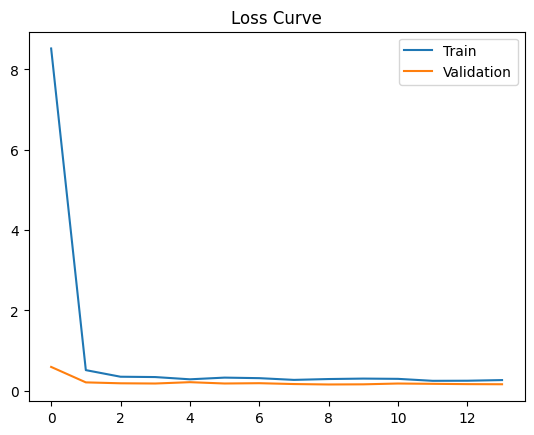

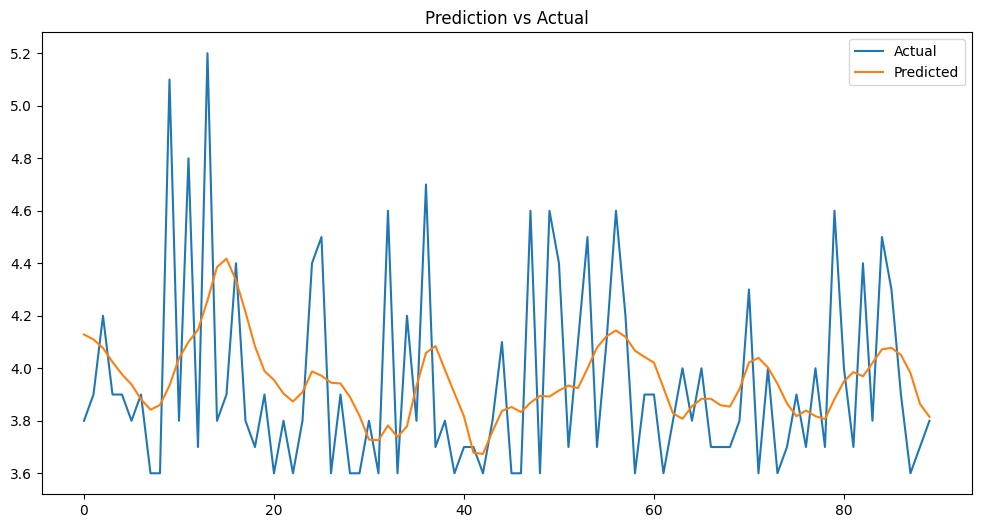

In [ ]:
# ============================================================
# INSTALL REQUIRED LIBRARY
# ============================================================
!pip install -q PyWavelets   # Install wavelet library (ensures reproducibility in Colab)

# ============================================================
# IMPORT LIBRARIES
# ============================================================
import numpy as np                      # Numerical operations
import pandas as pd                     # Data handling
import matplotlib.pyplot as plt         # Plotting
import pywt                             # Wavelet transform
import random                           # Random seed control

from sklearn.preprocessing import RobustScaler   # Robust scaling (handles outliers better)
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Evaluation metrics

from tensorflow.keras.models import Model        # Functional API model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

# ============================================================
# REPRODUCIBILITY (CRITICAL FOR RESEARCH)
# ============================================================
SEED = 42
np.random.seed(SEED)         # Fix NumPy randomness
random.seed(SEED)            # Fix Python randomness
tf.random.set_seed(SEED)     # Fix TensorFlow randomness

# ============================================================
# UPLOAD DATASET
# ============================================================
from google.colab import files
uploaded = files.upload()    # Upload earthquake.csv manually

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv("earthquake.csv")  # Read CSV file

# Convert Date column to datetime format (invalid dates → NaT)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows where Date or Magnitude is missing (critical fields)
df = df.dropna(subset=['Date', 'Magnitude'])

# Remove duplicate rows
df = df.drop_duplicates()

# Ensure optional columns exist (prevents crash if missing)
for col in ['Latitude', 'Longitude', 'Depth']:
    if col not in df.columns:
        df[col] = np.nan

# Filter unrealistic values (data cleaning step)
df = df[(df['Magnitude'] > -2) &
        (df['Latitude'].between(-90, 90) | df['Latitude'].isna()) &
        (df['Longitude'].between(-180, 180) | df['Longitude'].isna()) &
        ((df['Depth'] > -1) | df['Depth'].isna())]

# Sort dataset chronologically (VERY IMPORTANT for time-series)
df = df.sort_values('Date').reset_index(drop=True)

print("Final dataset size:", len(df))

# ============================================================
# FEATURE ENGINEERING (NO DATA LEAKAGE)
# ============================================================

# Rolling mean → captures local trend
df['SMA_5'] = df['Magnitude'].rolling(5).mean()

# Rolling max → captures extreme values
df['Rolling_Max'] = df['Magnitude'].rolling(5).max()

# Rolling std → captures volatility
df['Rolling_STD'] = df['Magnitude'].rolling(5).std()

# Time difference between earthquakes (temporal feature)
df['Inter_Event_Days'] = df['Date'].diff().dt.days

# Fill initial NaN values using backward fill
df = df.bfill()

# ============================================================
# TRAIN / VALIDATION / TEST SPLIT (TIME-SERIES SAFE)
# ============================================================
train_size = int(len(df) * 0.7)   # 70% training
val_size = int(len(df) * 0.15)    # 15% validation

# Chronological split (prevents future leakage)
train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size+val_size]
test_df = df.iloc[train_size+val_size:]

# ============================================================
# WAVELET PIPELINE (FIXED SHAPE ISSUE)
# ============================================================
def wavelet_pipeline(signal, wavelet='db4', level=5):
    n = len(signal)
    # Ensure level is valid for signal length
    max_level = pywt.dwt_max_level(n, pywt.Wavelet(wavelet).dec_len)
    level = min(level, max_level)

    # Perform wavelet decomposition
    coeffs = pywt.wavedec(signal, wavelet, level=level)

    def zero_coeffs_like(coeffs):
        return [np.zeros_like(c) for c in coeffs]

    # Reconstruction and trimming to ensure length matches input signal
    coeffs_A = zero_coeffs_like(coeffs)
    coeffs_A[0] = coeffs[0]
    A = pywt.waverec(coeffs_A, wavelet)[:n]

    coeffs_D1 = zero_coeffs_like(coeffs)
    if len(coeffs) > 1: coeffs_D1[1] = coeffs[1]
    D1 = pywt.waverec(coeffs_D1, wavelet)[:n]

    coeffs_D2 = zero_coeffs_like(coeffs)
    if len(coeffs) > 2: coeffs_D2[2] = coeffs[2]
    D2 = pywt.waverec(coeffs_D2, wavelet)[:n]

    coeffs_D3 = zero_coeffs_like(coeffs)
    if len(coeffs) > 3: coeffs_D3[3] = coeffs[3]
    D3 = pywt.waverec(coeffs_D3, wavelet)[:n]

    return np.column_stack([A, D1, D2, D3])

# Apply wavelet separately to each split (prevents leakage)
train_wave = wavelet_pipeline(train_df['Magnitude'])
val_wave = wavelet_pipeline(val_df['Magnitude'])
test_wave = wavelet_pipeline(test_df['Magnitude'])

# ============================================================
# EDGE TRIMMING (REMOVES WAVELET ARTIFACTS)
# ============================================================
EDGE = 10

def trim(x):
    return x[EDGE:-EDGE]

train_wave = trim(train_wave)
val_wave = trim(val_wave)
test_wave = trim(test_wave)

# Extract additional engineered features
train_extra = trim(train_df[['SMA_5','Rolling_Max','Rolling_STD','Inter_Event_Days']].values)
val_extra = trim(val_df[['SMA_5','Rolling_Max','Rolling_STD','Inter_Event_Days']].values)
test_extra = trim(test_df[['SMA_5','Rolling_Max','Rolling_STD','Inter_Event_Days']].values)

# Target values (Magnitude)
y_train = trim(train_df['Magnitude'].values)
y_val = trim(val_df['Magnitude'].values)
y_test = trim(test_df['Magnitude'].values)

# Combine wavelet + statistical features
X_train = np.hstack([train_wave, train_extra])
X_val = np.hstack([val_wave, val_extra])
X_test = np.hstack([test_wave, test_extra])

# ============================================================
# SCALING (TRAIN ONLY → NO LEAKAGE)
# ============================================================
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ============================================================
# CREATE SEQUENCES FOR LSTM
# ============================================================
SEQ = 10

def make_seq(X, y):
    Xs, ys = [], []
    for i in range(len(X)-SEQ):
        Xs.append(X[i:i+SEQ])
        ys.append(y[i+SEQ])
    return np.array(Xs), np.array(ys)

X_train, y_train = make_seq(X_train, y_train)
X_val, y_val = make_seq(X_val, y_val)
X_test, y_test = make_seq(X_test, y_test)

print("Train shape:", X_train.shape)

# ============================================================
# MODEL (BiLSTM)
# ============================================================
inp = Input(shape=(SEQ, X_train.shape[2]))
x = Bidirectional(LSTM(64, return_sequences=True))(inp)
x = Dropout(0.3)(x)
x = Bidirectional(LSTM(32))(x)
x = Dropout(0.3)(x)
out = Dense(1)(x)

model = Model(inp, out)
model.compile(optimizer='adam', loss='mse')
model.summary()

# ============================================================
# TRAINING
# ============================================================
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# ============================================================
# EVALUATION
# ============================================================
pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print("\n===== FINAL METRICS =====")
print("RMSE:", rmse)
print("MAE :", mae)

# ============================================================
# VISUALIZATION
# ============================================================
plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

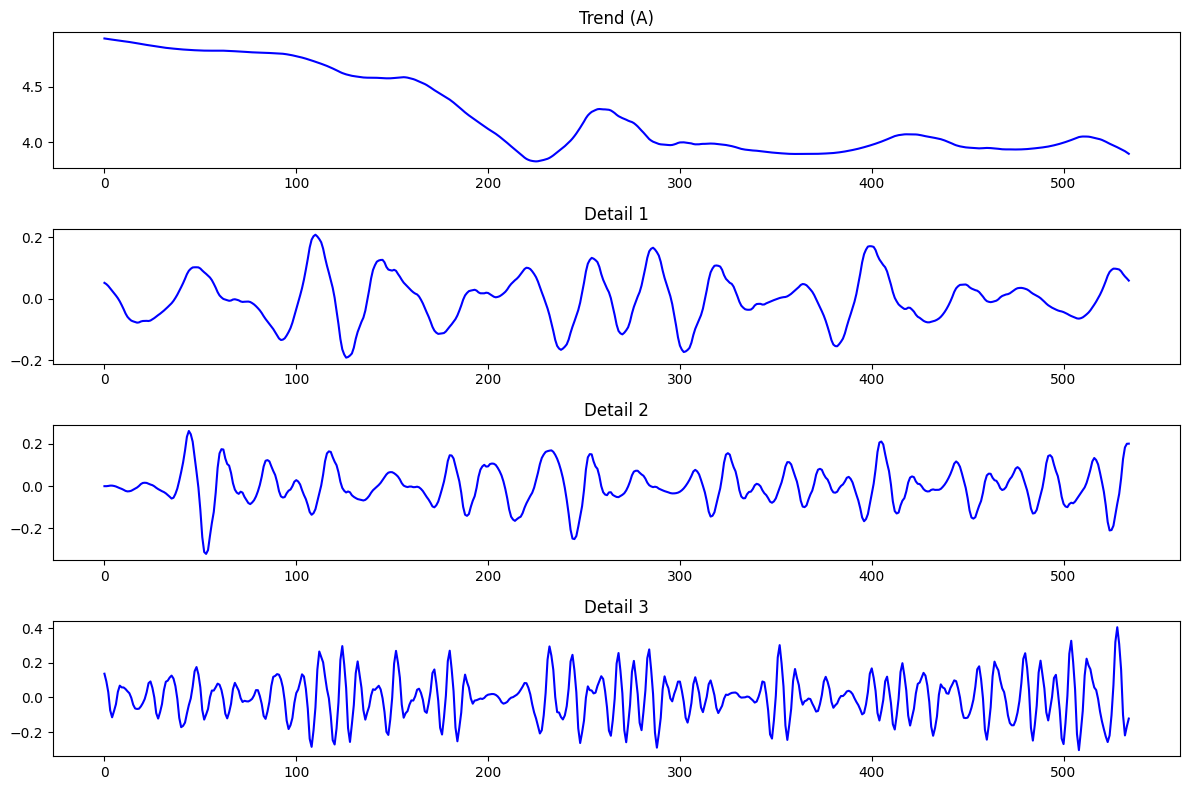

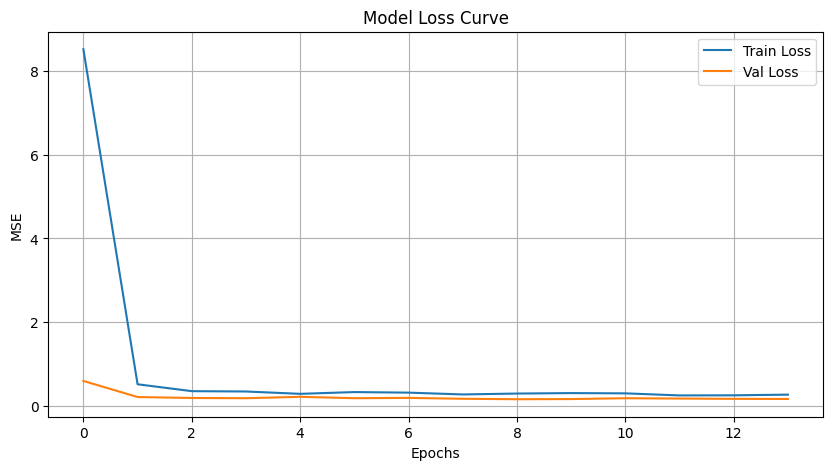

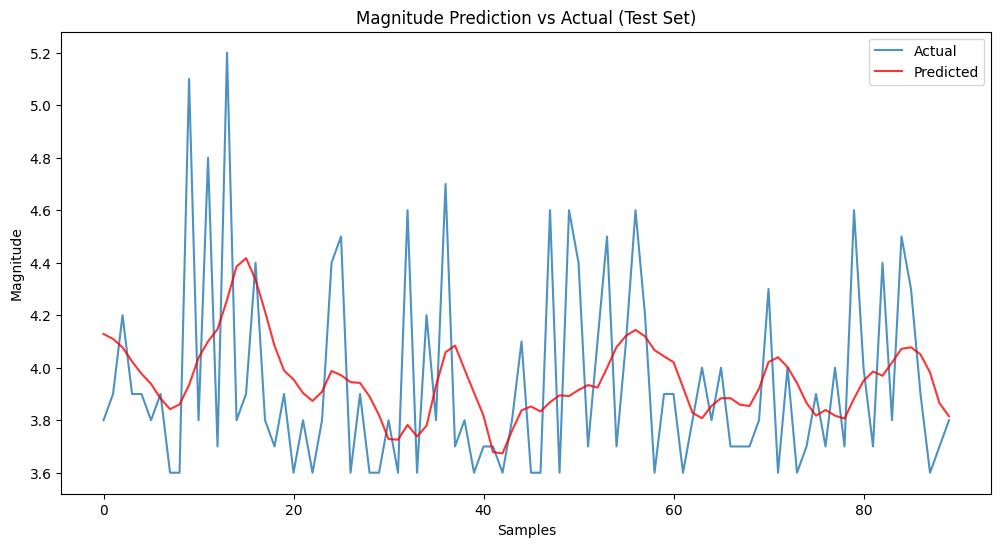

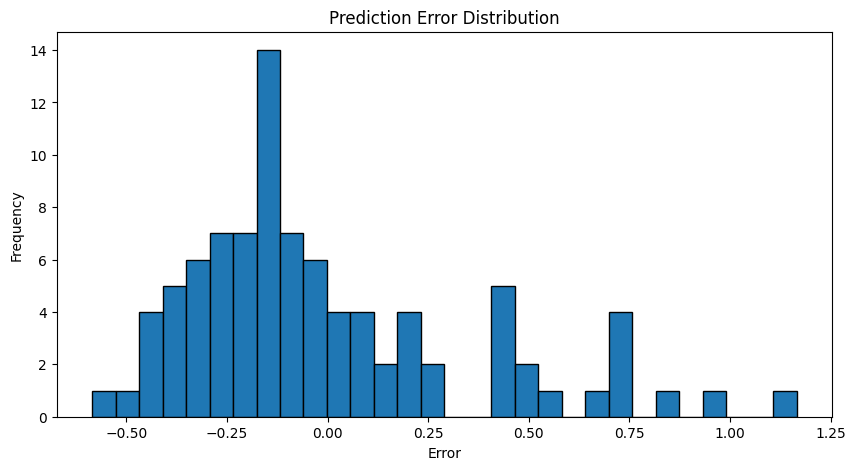

In [ ]:
import matplotlib.pyplot as plt

# 1. Wavelet Components (A, D1, D2, D3)
plt.figure(figsize=(12, 8))
titles = ['Trend (A)', 'Detail 1', 'Detail 2', 'Detail 3']
for i in range(4):
    plt.subplot(4, 1, i+1)
    plt.plot(train_wave[:, i], color='blue')
    plt.title(titles[i])
plt.tight_layout()
plt.show()

# 2. Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

# 3. Prediction vs Actual Magnitude
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', alpha=0.8)
plt.plot(pred, label='Predicted', alpha=0.8, color='red')
plt.title('Magnitude Prediction vs Actual (Test Set)')
plt.xlabel('Samples')
plt.ylabel('Magnitude')
plt.legend()
plt.show()

# 4. Error Distribution
plt.figure(figsize=(10, 5))
plt.hist(y_test - pred.flatten(), bins=30, edgecolor='k')
plt.title('Prediction Error Distribution')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()